In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 33.4 MB/s eta 0:00:00


In [2]:
import torch

# --- 1. GPU/Device Check ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ GPU not found. Running on CPU.")

✅ GPU Detected: Tesla T4


In [9]:
import pandas as pd
import numpy as np
import os
import warnings
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from scipy.stats import t, skew
from itertools import combinations

# Suppress warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Configuration & File Setup
# ==========================================

CONFIG = {
    'train_start': '2015-01-01',
    'train_end': '2022-12-31',
    'test_start': '2023-01-01',
    'test_end': '2025-12-31',
    'rolling_window': 252,      # Uses last 1 year of data (including Training data at the start)
    'transaction_cost': 0.001,  # 0.1% per trade side
    'cost_damping': 0.5,        # Factor to reduce cost impact during selection (1/2)
    'sideways_threshold': 0.25, # If |Mean|/Vol < 0.25, it's sideways
}

FILE_PATHS = [
    "/content/BAJFINANCE.csv", "/content/BHARTIARTL.csv", "/content/HCLTECH.csv",
    "/content/HDFCBANK.csv", "/content/HINDUNILVR.csv", "/content/ICICIBANK.csv",
    "/content/INFY.csv", "/content/MARUTI.csv", "/content/RELIANCE.csv", "/content/TCS.csv"
]

# ==========================================
# 2. Data Loading
# ==========================================

def load_specific_files(file_list):
    data = {}
    print("Loading data...")
    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"Warning: File not found: {file_path}")
            continue

        stock_name = os.path.basename(file_path).replace('.csv', '')
        try:
            df = pd.read_csv(file_path)
            # Handle potential date column variations
            date_col = 'Date' if 'Date' in df.columns else df.columns[0]
            # Explicitly set dayfirst=True for DD-MM-YYYY format
            df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)
            df.set_index(date_col, inplace=True)
            df.sort_index(inplace=True)

            # Remove non-trading days or garbage
            df = df[df['Close'] > 0]

            # Log Returns
            df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
            df.dropna(inplace=True)

            data[stock_name] = df
        except Exception as e:
            print(f"Error loading {stock_name}: {e}")

    return data

# ==========================================
# 3. Modeling Helper Functions
# ==========================================

def fit_arima_garch(series):
    """
    Fits ARIMA(1,0,1) + GARCH(1,1).
    Returns: Forecast Mean (mu), Forecast Sigma, Residuals
    """
    # 1. ARIMA for Mean
    try:
        arima = ARIMA(series, order=(1,0,1)).fit()
        mu = arima.forecast(steps=1).iloc[0]
        resid = arima.resid
    except:
        mu = series.mean()
        resid = series - mu

    # 2. GARCH for Volatility
    # Scale up for optimization stability
    scaled_resid = resid * 100
    try:
        garch = arch_model(scaled_resid, vol='Garch', p=1, q=1, dist='Normal')
        res = garch.fit(disp='off', show_warning=False)
        var_forecast = res.forecast(horizon=1).variance.iloc[-1, 0]
        sigma = np.sqrt(var_forecast) / 100
        std_resid = res.std_resid
    except:
        sigma = series.std()
        std_resid = resid / sigma

    return mu, sigma, std_resid

def calculate_turnover_cost(current_pair, candidate_pair, cost_per_side=0.001):
    """
    Calculates the transaction cost percentage to switch portfolios.
    Weight is assumed 50/50 for both pairs.
    """
    if current_pair is None:
        return cost_per_side * 2 # Initial entry (buy both)

    # Convert to sets for easy comparison
    curr_set = set(current_pair)
    cand_set = set(candidate_pair)

    # Stocks to Sell (in current but not in candidate)
    to_sell = curr_set - cand_set
    # Stocks to Buy (in candidate but not in current)
    to_buy = cand_set - curr_set

    # Cost calculation:
    # We hold 0.5 of each stock.
    # Cost = (0.5 * cost * num_sells) + (0.5 * cost * num_buys)
    cost = (len(to_sell) * 0.5 * cost_per_side) + (len(to_buy) * 0.5 * cost_per_side)

    return cost

# ==========================================
# 4. Backtesting Engine
# ==========================================

def run_strategy(data_dict):
    if not data_dict:
        return pd.DataFrame()

    print(f"Initializing Strategy (Test: {CONFIG['test_start']} to {CONFIG['test_end']})...")

    # Generate Trading Schedule (Weekly Mondays)
    ref_df = list(data_dict.values())[0]
    dates = ref_df.loc[CONFIG['test_start']:CONFIG['test_end']].index
    weekly_dates = [d for d in dates if d.dayofweek == 0]

    # Pre-calculate Volatility Thresholds (Training Phase)
    print("Calibrating Volatility Regimes using Training Data (2015-2022)...")
    vol_thresholds = {}
    for ticker, df in data_dict.items():
        # Strictly use Training Data for Volatility Thresholds
        train = df.loc[:CONFIG['train_end']]
        if len(train) < 50:
            vol_thresholds[ticker] = 0.02 # Fallback
            continue
        # 21-day rolling annualized vol
        hist_vol = train['Log_Ret'].rolling(21).std()
        # "High" defined as > 66th percentile of the HISTORICAL training data
        vol_thresholds[ticker] = np.percentile(hist_vol.dropna(), 66)

    portfolio_value = 100000.0
    current_pair = None # Track what we are currently holding
    history = []

    print("\nStarting Weekly Tournament...")
    print(f"{'Date':<12} | {'Prob_Up':<8} | {'Pair':<25} | {'Weekly_Return':<15} | {'Total_Value':<15}")
    print("-" * 85)

    for i, current_date in enumerate(weekly_dates):

        # --- A. Gather Forecasts ---
        forecasts = {}
        for ticker, df in data_dict.items():
            # Grab data UP TO current_date (including training history)
            sub_df = df.loc[:current_date].iloc[:-1] # Exclude today to prevent lookahead

            # Ensure we have enough history
            if len(sub_df) < 252: continue

            # Take the last 252 days (Rolling Window)
            recent_data = sub_df['Log_Ret'].iloc[-CONFIG['rolling_window']:]

            # Forecast
            mu, sigma, std_resid = fit_arima_garch(recent_data)

            # Rolling t-dist degrees of freedom AND skew
            try:
                nu = t.fit(std_resid[-90:])[0]
                sk = skew(std_resid[-90:]) # Calculate Skewness of residuals
            except:
                nu = 30
                sk = 0

            forecasts[ticker] = {
                'mu': mu,
                'sigma': sigma,
                'nu': nu,
                'skew': sk, # Store skew
                'returns': sub_df['Log_Ret']
            }

        if len(forecasts) < 2: continue

        # --- B. Covariance Matrix (Last 90 days) ---
        tickers = list(forecasts.keys())
        common_idx = forecasts[tickers[0]]['returns'].index[-90:]
        aligned_rets = pd.DataFrame({t: forecasts[t]['returns'] for t in tickers}).reindex(common_idx).fillna(0)
        cov_matrix = aligned_rets.cov()

        # --- C. Tournament (Pair Selection) ---
        best_pair = None
        best_score = -np.inf
        best_prob_up = 0.5

        for pair in combinations(tickers, 2):
            s1, s2 = pair
            f1, f2 = forecasts[s1], forecasts[s2]

            # 1. Expected Return (Mean of ARIMA forecasts)
            port_mu = 0.5 * f1['mu'] + 0.5 * f2['mu']

            # 2. Transaction Cost
            estimated_cost = calculate_turnover_cost(current_pair, pair, CONFIG['transaction_cost'])
            adjusted_mu = port_mu - (estimated_cost * CONFIG['cost_damping'])

            # 3. Expected Volatility
            hist_cov = cov_matrix.loc[s1, s2]
            var_term = (0.25 * f1['sigma']**2) + (0.25 * f2['sigma']**2) + (2 * 0.5 * 0.5 * hist_cov)
            port_sigma = np.sqrt(max(var_term, 1e-6))

            # --- PROBABILITY OF UP CALCULATION  ---

            avg_nu = (f1['nu'] + f2['nu']) / 2
            avg_skew = (f1['skew'] + f2['skew']) / 2

            # Standard t-score (How many sigmas is 0 away from our mean?)
            z_score = (0 - port_mu) / port_sigma

            # If skew is significant, adjust the z-score boundary
            # Simple Cornish-Fisher expansion adjustment for the threshold
            adj_z = z_score + (avg_skew / 6) * (z_score**2 - 1)

            # Calculate Prob(Return > 0)
            # 1 - CDF(adjusted_threshold)
            prob_up = 1.0 - t.cdf(adj_z, avg_nu)
            # ------------------------------------------------

            # 4. Regime Penalty
            high_vol_thresh = (vol_thresholds[s1] + vol_thresholds[s2]) / 2
            is_high_vol = port_sigma > high_vol_thresh
            is_sideways = (abs(port_mu) / port_sigma) < CONFIG['sideways_threshold']

            # Base Score (Sharpe)
            score = adjusted_mu / port_sigma

            if is_high_vol and is_sideways:
                score -= 10.0

            if score > best_score:
                best_score = score
                best_pair = pair
                best_prob_up = prob_up

        # --- D. Execution & Returns ---
        if best_pair:
            try:
                # Determine Exit Date (Next Monday)
                next_date = weekly_dates[i+1] if i+1 < len(weekly_dates) else df.index[-1]

                # 1. Deduct ACTUAL Transaction Costs
                real_cost_pct = calculate_turnover_cost(current_pair, best_pair, CONFIG['transaction_cost'])
                portfolio_value *= (1 - real_cost_pct)

                # 2. Calculate Market Return for the week
                p1_start = data_dict[best_pair[0]].loc[current_date]['Close']
                p1_end = data_dict[best_pair[0]].loc[:next_date].iloc[-1]['Close']

                p2_start = data_dict[best_pair[1]].loc[current_date]['Close']
                p2_end = data_dict[best_pair[1]].loc[:next_date].iloc[-1]['Close']

                ret1 = (p1_end / p1_start) - 1
                ret2 = (p2_end / p2_start) - 1

                # Raw Market Return
                market_ret = 0.5 * ret1 + 0.5 * ret2

                # Net Return (considering the cost we just paid)
                net_weekly_return = ((1 - real_cost_pct) * (1 + market_ret)) - 1

                # Update Total Value
                portfolio_value *= (1 + market_ret)

                history.append({
                    'Date': current_date,
                    'Prob_Up': best_prob_up,
                    'Pair': best_pair,
                    'Weekly_Return': net_weekly_return,
                    'Total_Value': portfolio_value
                })

                # Update holding
                current_pair = best_pair

                # Print Row
                print(f"{current_date.date()}   | {best_prob_up:.4f}   | {str(best_pair):<25} | {net_weekly_return:.4%}       | ${portfolio_value:,.2f}")

            except KeyError:
                pass

    return pd.DataFrame(history)

# ==========================================
# 5. Main Execution
# ==========================================

if __name__ == "__main__":
    # Load the specified files
    data_map = load_specific_files(FILE_PATHS)

    if len(data_map) > 0:
        results = run_strategy(data_map)

        if not results.empty:
            results.set_index('Date', inplace=True)

            # Save to CSV
            output_file = "final_output.csv"
            results.to_csv(output_file)
            print(f"\nResults successfully saved to {output_file}")

            # Calculate Total Cumulative Return based on final value
            total_ret = (results['Total_Value'].iloc[-1] / 100000.0) - 1

            print("\n" + "="*40)
            print("FINAL PERFORMANCE SUMMARY (2023-2025)")
            print("="*40)
            print(f"Final Value:  ${results['Total_Value'].iloc[-1]:,.2f}")
            print(f"Total Return: {total_ret:.2%}")
            print("="*40)
        else:
            print("Backtest finished with no trades.")
    else:
        print("No valid CSV files found in the paths provided.")

Loading data...
Initializing Strategy (Test: 2023-01-01 to 2025-12-31)...
Calibrating Volatility Regimes using Training Data (2015-2022)...

Starting Weekly Tournament...
Date         | Prob_Up  | Pair                      | Weekly_Return   | Total_Value    
-------------------------------------------------------------------------------------
2023-01-02   | 0.5883   | ('BHARTIARTL', 'HINDUNILVR') | 1.4424%       | $101,442.37
2023-01-09   | 0.5740   | ('BHARTIARTL', 'HINDUNILVR') | -4.1900%       | $97,191.95
2023-01-16   | 0.5396   | ('HINDUNILVR', 'MARUTI')  | 0.1071%       | $97,296.01
2023-01-23   | 0.5705   | ('BHARTIARTL', 'HDFCBANK') | -2.1196%       | $95,233.70
2023-01-30   | 0.5456   | ('BHARTIARTL', 'HDFCBANK') | 2.4014%       | $97,520.63
2023-02-06   | 0.6288   | ('HDFCBANK', 'ICICIBANK') | -0.0789%       | $97,443.72
2023-02-13   | 0.5245   | ('HCLTECH', 'HDFCBANK')   | -0.5210%       | $96,936.04
2023-02-20   | 0.4875   | ('BHARTIARTL', 'HCLTECH') | -3.2043%       | $93,

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. Performance Metrics Analysis
# ==========================================
def analyze_performance(results_df, risk_free_rate=0.0, periods_per_year=52):
    """
    Analyzes portfolio performance metrics.
    """
    if results_df.empty:
        print("No data to analyze.")
        return

    # Create a clean copy
    df = results_df.copy()

    # 1. Standardize Columns
    if 'Total_Value' in df.columns:
        df.rename(columns={'Total_Value': 'Value'}, inplace=True)
    if 'Return' not in df.columns and 'Weekly_Return' in df.columns:
        df.rename(columns={'Weekly_Return': 'Return'}, inplace=True)

    # 2. Add Start Row (Calibration Step)
    # We infer the "start date" as 1 week before the first result
    start_date = df.index[0] - pd.Timedelta(weeks=1)
    start_capital = 100000.0

    # Create the Day 0 row
    start_row = pd.DataFrame({
        'Value': [start_capital],
        'Return': [0.0]
    }, index=[start_date])

    # Prepend to the dataframe for calculation
    # (We use this extended DF for drawdown and equity curve calc,
    # but strictly use the original DF for statistics like Volatility/Sharpe to avoid skewing with 0.0)
    df_extended = pd.concat([start_row, df])

    # --- Metrics Calculation ---
    final_val = df['Value'].iloc[-1]
    total_return = (final_val / start_capital) - 1

    # CAGR
    total_days = (df.index[-1] - start_date).days
    years = total_days / 365.25
    cagr = (final_val / start_capital) ** (1 / years) - 1 if years > 0 else 0

    # Volatility & Sharpe (Use original df to exclude the artificial Day 0 zero-return)
    volatility = df['Return'].std() * np.sqrt(periods_per_year)
    mean_ret = df['Return'].mean() * periods_per_year
    sharpe = (mean_ret - risk_free_rate) / volatility if volatility > 0 else 0

    # Drawdown (Use extended df to capture drop from initial 100k if immediate loss)
    peak = df_extended['Value'].cummax()
    drawdown = (df_extended['Value'] - peak) / peak
    max_drawdown = drawdown.min()

    # --- Report ---
    print("\n" + "="*45)
    print(f"PERFORMANCE REPORT ({df.index[0].date()} to {df.index[-1].date()})")
    print("="*45)
    print(f"{'Initial Capital':<25} : ${start_capital:,.2f}")
    print(f"{'Final Value':<25} : ${final_val:,.2f}")
    print(f"{'Total Return':<25} : {total_return:.2%}")
    print(f"{'CAGR':<25} : {cagr:.2%}")
    print(f"{'Annualized Volatility':<25} : {volatility:.2%}")
    print("-" * 45)
    print(f"{'Sharpe Ratio':<25} : {sharpe:.4f}")
    print(f"{'Max Drawdown':<25} : {max_drawdown:.2%}")
    print("="*45 + "\n")

# ==========================================
# 2. Recalibrated Plotting
# ==========================================
def plot_backtest_results(results_df):
    """
    Plots Equity Curve starting explicitly from 100k.
    """
    if results_df.empty: return

    df = results_df.copy()
    if 'Total_Value' in df.columns: df.rename(columns={'Total_Value': 'Value'}, inplace=True)
    if 'Weekly_Return' in df.columns: df.rename(columns={'Weekly_Return': 'Return'}, inplace=True)

    # --- RECALIBRATION: Insert Day 0 ---
    start_date = df.index[0] - pd.Timedelta(weeks=1)
    start_row = pd.DataFrame({'Value': [100000.0], 'Return': [0.0]}, index=[start_date])
    df_plot = pd.concat([start_row, df])

    # Drawdown Calc on extended data
    peak = df_plot['Value'].cummax()
    df_plot['Drawdown'] = (df_plot['Value'] - peak) / peak

    # Plot
    plt.style.use('bmh')
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # Equity
    ax1.plot(df_plot.index, df_plot['Value'], color='#1f77b4', linewidth=2)
    ax1.set_title('Portfolio Equity Curve (Starts at $100k)', fontsize=12)
    ax1.set_ylabel('Value ($)')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Drawdown
    ax2.fill_between(df_plot.index, df_plot['Drawdown'], 0, color='#d62728', alpha=0.3)
    ax2.plot(df_plot.index, df_plot['Drawdown'], color='#d62728', linewidth=1)
    ax2.set_title('Drawdown (%)', fontsize=12)
    ax2.set_ylabel('Drawdown')
    ax2.grid(True, linestyle='--', alpha=0.7)

    # Returns (Skip the artificial first row for bars, as it's 0.0)
    # We plot returns for the actual trading weeks
    colors = ['#2ca02c' if r >= 0 else '#d62728' for r in df['Return']]
    ax3.bar(df.index, df['Return'], color=colors, width=5, alpha=0.8)
    ax3.set_title('Weekly Returns', fontsize=12)
    ax3.set_ylabel('Return')
    ax3.axhline(0, color='black', linewidth=0.8)
    ax3.grid(True, linestyle='--', alpha=0.7)

    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. Recalibrated Comparative Study
# ==========================================
def run_comparative_study(strategy_results, data_dict, initial_capital=100000.0):
    if strategy_results.empty or not data_dict: return

    print("Building Recalibrated Benchmark...")

    # Prepare Strategy DF
    strat_df = strategy_results.copy()
    col_name = 'Total_Value' if 'Total_Value' in strat_df.columns else 'Value'
    strat_df = strat_df[[col_name]].rename(columns={col_name: 'Strategy_Value'})

    # --- RECALIBRATION: Define Timeframe ---
    # Strategy result dates (End of Week 1, End of Week 2...)
    result_dates = strat_df.index

    # We infer Day 0 (Start Date)
    start_date = result_dates[0] - pd.Timedelta(weeks=1)

    # --- Build Benchmark ---
    tickers = list(data_dict.keys())
    weight = 1.0 / len(tickers)

    # Initialize benchmark history with Day 0
    bench_history = [{'Date': start_date, 'Benchmark_Value': initial_capital}]
    current_bench_val = initial_capital

    # Loop through each reporting period
    # We iterate from start_date to the first result, then first to second...
    # To simplify: We just need to calculate the return between [prev_date] and [curr_date]

    # Full list of dates including start
    all_dates = [start_date] + list(result_dates)

    for i in range(1, len(all_dates)):
        prev_date = all_dates[i-1]
        curr_date = all_dates[i]

        # Calculate Equal-Weight Return for this specific interval
        period_return = 0.0

        for ticker in tickers:
            try:
                # Price at previous date (Entry)
                if prev_date in data_dict[ticker].index:
                    p0 = data_dict[ticker].loc[prev_date]['Close']
                else:
                    # Fallback: closest date before
                    p0 = data_dict[ticker].loc[:prev_date].iloc[-1]['Close']

                # Price at current date (Exit)
                if curr_date in data_dict[ticker].index:
                    p1 = data_dict[ticker].loc[curr_date]['Close']
                else:
                    p1 = data_dict[ticker].loc[:curr_date].iloc[-1]['Close']

                stock_ret = (p1 / p0) - 1
                period_return += (weight * stock_ret)

            except:
                pass # Missing data contributes 0 return (cash)

        # Update Value
        current_bench_val *= (1 + period_return)
        bench_history.append({'Date': curr_date, 'Benchmark_Value': current_bench_val})

    # Create Benchmark DF
    bench_df = pd.DataFrame(bench_history).set_index('Date')

    # --- Merge with Strategy (Adding Day 0 to Strategy too) ---
    strat_start_row = pd.DataFrame({'Strategy_Value': [initial_capital]}, index=[start_date])
    strat_full = pd.concat([strat_start_row, strat_df])

    full_comp = strat_full.join(bench_df, how='inner')

    # Stats
    strat_ret = (full_comp['Strategy_Value'].iloc[-1] / initial_capital) - 1
    bench_ret = (full_comp['Benchmark_Value'].iloc[-1] / initial_capital) - 1
    alpha = strat_ret - bench_ret

    print("\n" + "="*45)
    print("COMPARISON RESULTS")
    print("="*45)
    print(f"Strategy Final   : ${full_comp['Strategy_Value'].iloc[-1]:,.2f}")
    print(f"Benchmark Final  : ${full_comp['Benchmark_Value'].iloc[-1]:,.2f}")
    print(f"Alpha            : {alpha:.2%}")
    print("="*45)

    # Plot
    plt.style.use('bmh')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Normalize to 100 for visual comparison
    strat_norm = (full_comp['Strategy_Value'] / initial_capital) * 100
    bench_norm = (full_comp['Benchmark_Value'] / initial_capital) * 100

    ax.plot(full_comp.index, strat_norm, label='Strategy', color='#1f77b4', linewidth=2)
    ax.plot(full_comp.index, bench_norm, label='Equal-Weight Benchmark', color='gray', linestyle='--')

    ax.fill_between(full_comp.index, strat_norm, bench_norm,
                    where=(strat_norm >= bench_norm), color='green', alpha=0.1)
    ax.fill_between(full_comp.index, strat_norm, bench_norm,
                    where=(strat_norm < bench_norm), color='red', alpha=0.1)

    ax.set_title('Recalibrated Comparison (Base 100)', fontsize=14)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


PERFORMANCE REPORT (2023-01-02 to 2025-12-29)
Initial Capital           : $100,000.00
Final Value               : $172,445.43
Total Return              : 72.45%
CAGR                      : 19.85%
Annualized Volatility     : 16.43%
---------------------------------------------
Sharpe Ratio              : 1.2563
Max Drawdown              : -9.63%



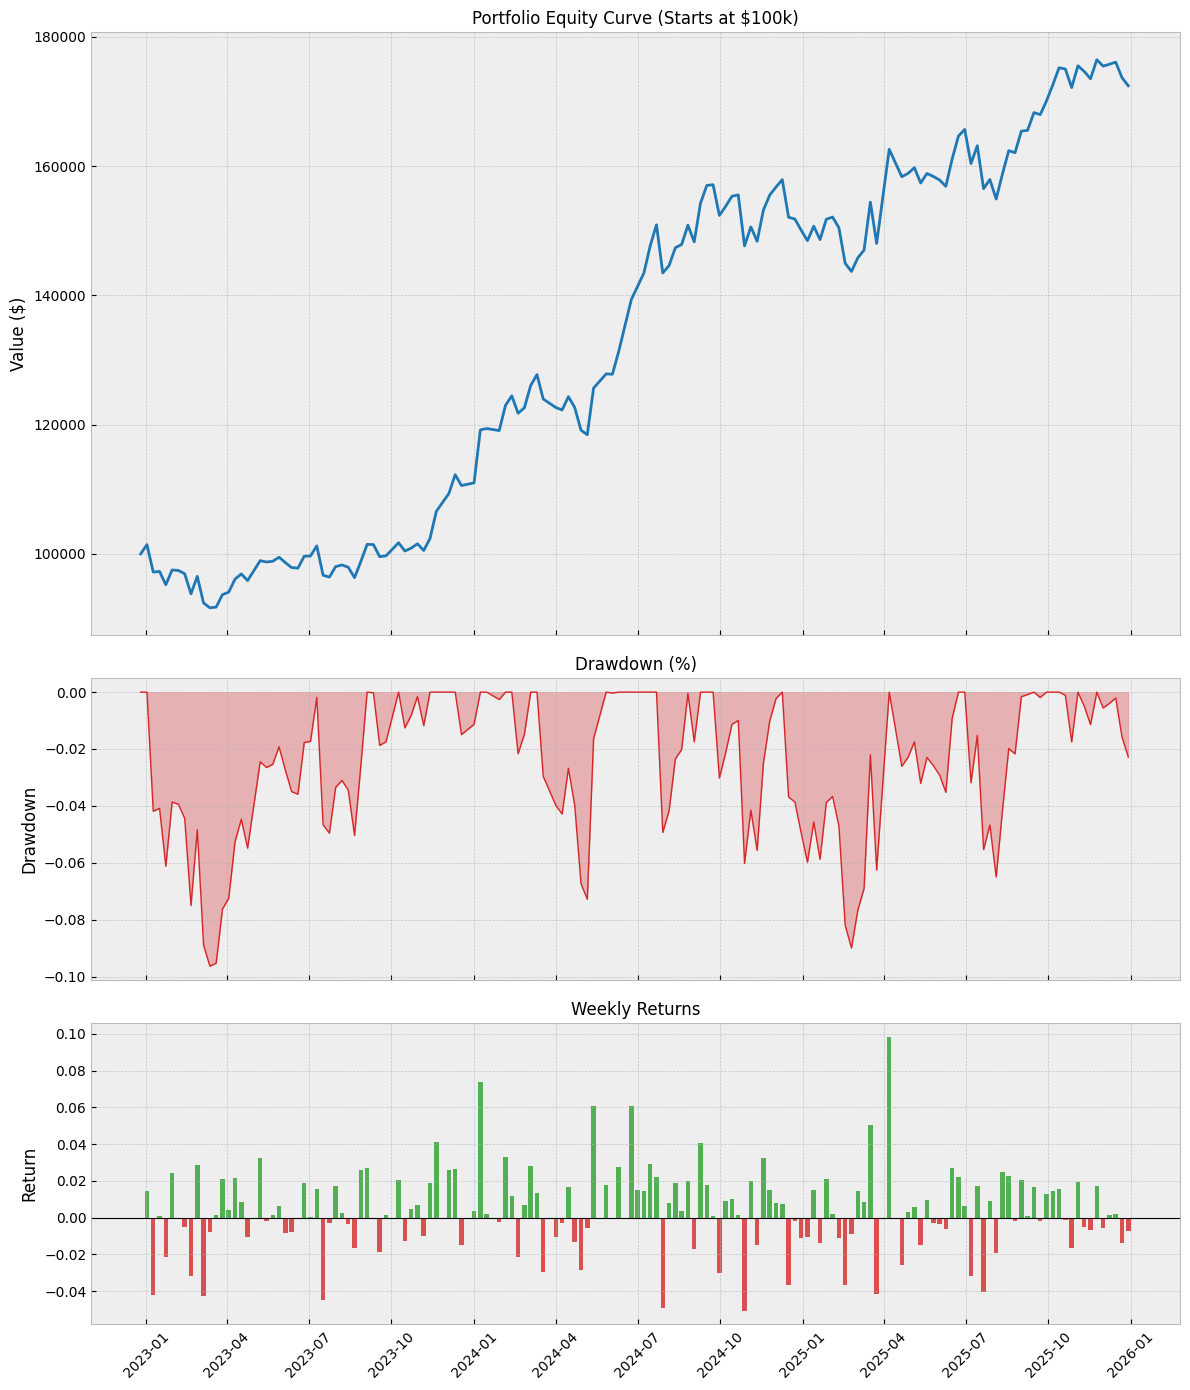

Building Recalibrated Benchmark...

COMPARISON RESULTS
Strategy Final   : $172,445.43
Benchmark Final  : $153,633.92
Alpha            : 18.81%


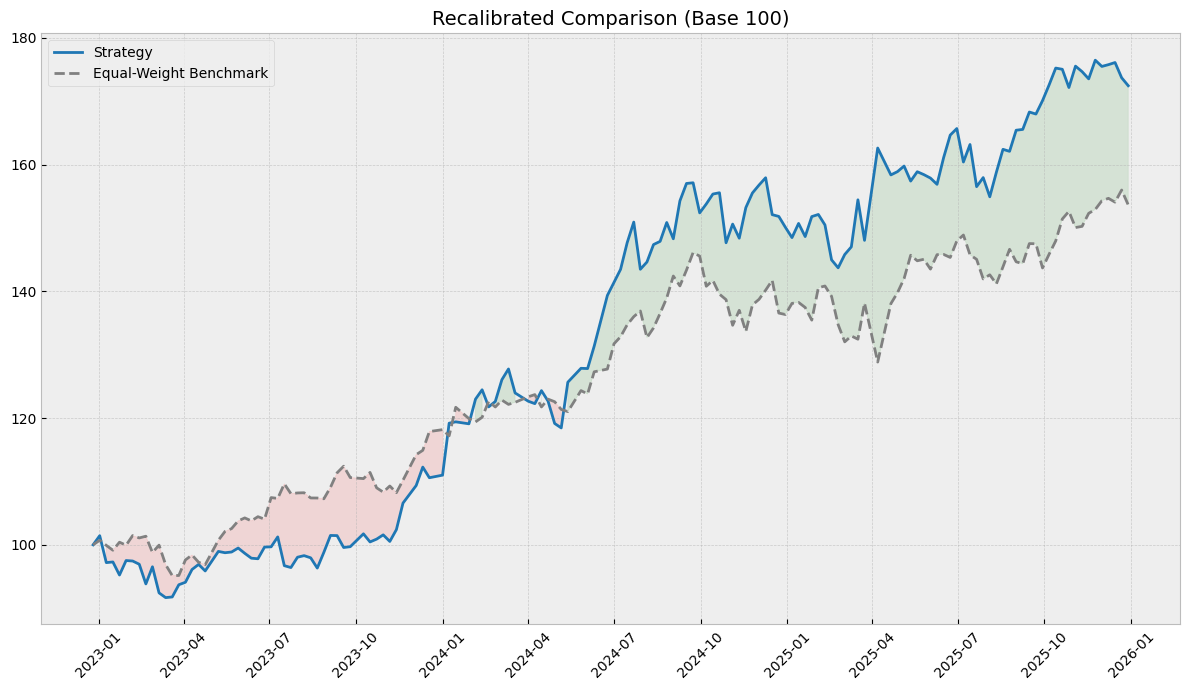

In [13]:
analyze_performance(results)
plot_backtest_results(results)
run_comparative_study(results, data_map)